# Study 783 — IPO-Deal-Of-Year 🏦

*For the curious.* Every year the bankers crown an **'IPO of the year'** — the biggest, splashiest, most oversubscribed debut on the tape. Folklore (an old cousin of Ritter's IPO-underperformance result) says the loudest deals then lag: the hype prices the pop and the newly-public stock drifts down. We put 17 marquee US debuts (Facebook → Reddit) on the stand and measured their forward return against SPY. The answer is a **split decision** — with a fat-tailed twist.

## The claim, and the honest caveat

We anchor on each name's **first trading close** and measure its **abnormal** return (name − SPY) at 3, 6 and 12 months. **Selection is *ex post* by design** — these are the debuts we remember *because* they were the marquee deal, and you can't buy 'the IPO of the year' at its open (the crown is awarded later). So this is a *descriptive* autopsy, not a live rule — which already caps tradability at **Mirage**.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ipo_deal_of_year import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching marquee names + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} marquee IPOs resolved")


panel loaded; 17 of 17 marquee IPOs resolved


## The marquee-IPO calendar we test (hardcoded real tickers + first-trade dates)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['ticker','first_trade','deal'])

,ticker,first_trade,deal
0,META,2012-05-18,Facebook — largest tech IPO of 2012
1,BABA,2014-09-19,Alibaba — largest IPO ever at the time (2014)
2,SNAP,2017-03-02,Snap — marquee consumer-tech debut of 2017
3,LYFT,2019-03-29,"Lyft — first ride-hail listing, 2019"
4,BYND,2019-05-02,Beyond Meat — best-performing IPO pop of 2019
5,UBER,2019-05-10,Uber — most-anticipated deal of 2019
6,PLTR,2020-09-30,"Palantir — headline direct listing, 2020"
7,DASH,2020-12-09,"DoorDash — marquee pandemic debut, 2020"
8,ABNB,2020-12-10,"Airbnb — deal of the year, 2020"
9,RBLX,2021-03-10,"Roblox — headline direct listing, 2021"


## The picture: mean cumulative abnormal return after the debut

Offset 0 is the first close; the line traces the average name-minus-SPY path over the first year.

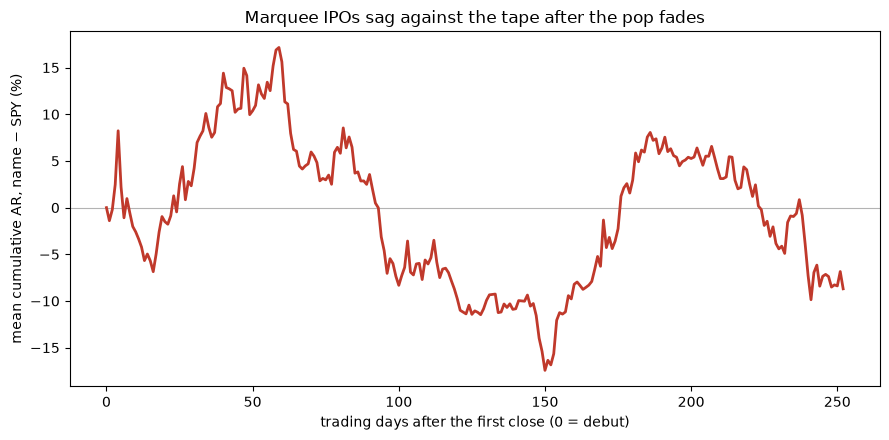

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#c0392b', lw=2)
ax.set_xlabel('trading days after the first close (0 = debut)')
ax.set_ylabel('mean cumulative AR, name − SPY (%)')
ax.set_title('Marquee IPOs sag against the tape after the pop fades')
plt.tight_layout(); plt.show()

## The other picture: it's all skew

The *mean* is a wash because a handful of monsters (Palantir, Reddit, Arm) drown out the many losers. Look at the 12-month ledger per name:

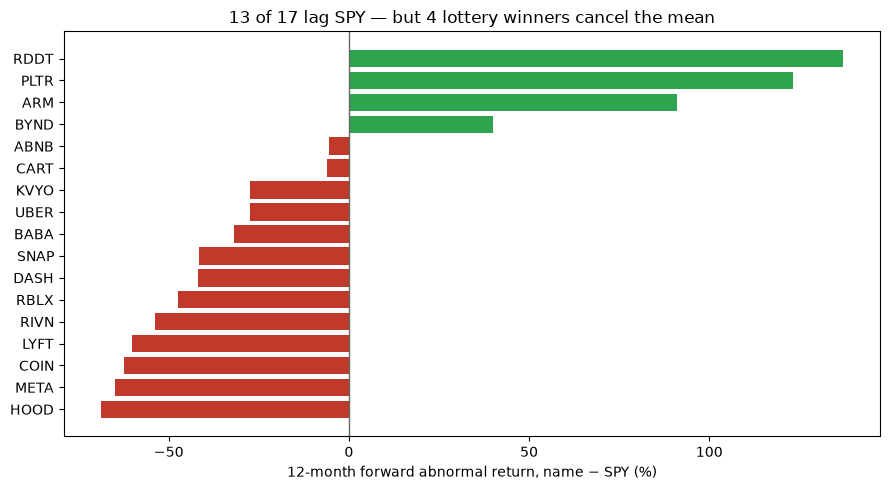

In [4]:
d = inc.sort_values('fwd_12m')
fig, ax = plt.subplots(figsize=(9, 5))
cols = ['#2ea44f' if v > 0 else '#c0392b' for v in d['fwd_12m']]
ax.barh(d['ticker'], d['fwd_12m']*100, color=cols)
ax.axvline(0, color='0.4', lw=1)
ax.set_xlabel('12-month forward abnormal return, name − SPY (%)')
ax.set_title('13 of 17 lag SPY — but 4 lottery winners cancel the mean')
plt.tight_layout(); plt.show()

## The numbers

| horizon | mean AR | *t* | beat SPY |
|---|--:|--:|--:|
| 3-month | **+7.96%** | +0.53 | 6/17 |
| 6-month | -11.06% | -0.89 | 5/17 |
| 12-month | -8.70% | -0.54 | 4/17 |

So: **most** marquee debuts (13 of 17) trail SPY over their first year, and the typical one is ~9% behind — but the *mean* is statistically a wash (*t* = -0.54) because Palantir (+123%), Reddit (+137%) and Arm (+91%) blow the average back to noise. And at 3 months the basket is actually *up* +7.96% (the pop). The 'underperformance' is real in the median but sign-flips with horizon and never clears significance.

In [5]:
for label, col in [('3-month','fwd_3m'),('6-month','fwd_6m'),('12-month','fwd_12m')]:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<10s} n={s["n"]:2d}  mean={s["mean"]*100:+.2f}%  t={s["t"]:+.3f}  beat SPY {hr["k"]}/{hr["n"]}')

3-month    n=17  mean=+7.96%  t=+0.530  beat SPY 6/17
6-month    n=17  mean=-11.06%  t=-0.887  beat SPY 5/17
12-month   n=17  mean=-8.70%  t=-0.541  beat SPY 4/17


## So what?

The bankers' 'IPO of the year' does tend to disappoint the *typical* buyer — three in four lag the index over the following year — but as a **basket mean** it's a coin-flip, and as a **trade** it's a mirage: you can't buy the crown at the open, the payoff is dominated by a few un-shortable lottery winners, and nothing clears significance. Verdict: **Weak signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.